# Yeti Travel — Customer Churn Prediction

**Machine Learning & Business Applications — Group Project**

## Business Context

Yeti Travel is a travel agency specialised in **school trips**. Over the past year
the company has registered a concerning **drop in sales, especially among repeat customers**.
Since most of the revenue comes from loyal clients, this threatens the continuity of the
business.

Our goal is to:

1. Build a **predictive model** that estimates the probability that a client (a school)
   will come back the following year (`Retained = 1`) or churn (`Retained = 0`).
2. Identify the **most informative features** of loyal customers, so that the agency can
   design targeted retention strategies (personalised offers, tighter relationships with
   high-risk schools, etc.).

## Data

The data is split across three departments, each with its own snapshot at the end of
"year 1":

- **Sales** — trip-level commercial info (program, grades, travel mode, dates, passengers).
- **Finance** — financial info (tuition, insurance take-up, revenue, payment modality).
- **CRM** — school-level info (school type, size, region, parent meetings, income level).

The target `Retained` lives in the Sales dataset.


## 1. Setup and imports

We use the standard data-science stack: `pandas`/`numpy` for data handling,
`matplotlib`/`seaborn` for visualisation, and `scikit-learn` for the full ML pipeline
(preprocessing, cross-validation, models).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Loading the data

We load both the **training (`_model`)** and the **test (`_test`)** versions of the
three datasets. The training set is labelled (`Retained` is known) and will be used
to fit the model. The test set is unlabelled — our model's predictions on it are the
deliverable.

We store every dataframe in a single dictionary so the loading logic stays DRY and we
can loop over them for a quick shape check.


In [2]:
path = 'data/'

datasets = [
    ('sales',   'sales_model.csv',   'sales_test.csv'),
    ('finance', 'finance_model.csv', 'finance_test.csv'),
    ('crm',     'crm_model.csv',     'crm_test.csv'),
]

# Load everything into a dict for later reuse
data = {}
for name, train_file, test_file in datasets:
    data[f'{name}_train'] = pd.read_csv(path + train_file)
    data[f'{name}_test']  = pd.read_csv(path + test_file)

print("Training shapes:")
for name, _, _ in datasets:
    print(f"  {name}_train: {data[f'{name}_train'].shape}")
print("\nTest shapes:")
for name, _, _ in datasets:
    print(f"  {name}_test:  {data[f'{name}_test'].shape}")

# Detailed overview (like your first script) for every dataframe
for key, df in data.items():
    print(f"\n{'='*40}")
    print(f"{key}: {df.shape}")
    print(df.head(3).to_string())
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print("\nMissing values:")
        print(missing)
    else:
        print("\nNo missing values.")

Training shapes:
  sales_train: (4153, 24)
  finance_train: (4151, 12)
  crm_train: (4148, 20)

Test shapes:
  sales_test:  (630, 24)
  finance_test:  (630, 12)
  crm_test:  (630, 20)

sales_train: (4153, 24)
  ID_SALES Program_Code  From_Grade  To_Grade Group_State  Days Travel_Type Departure_Date Return_Date   Early_RPL  Latest_RPL  Cancelled_Pax  Total_Discount_Pax Initial_System_Date SPR_Product_Type  FPP  Total_Pax DepartureMonth GroupGradeTypeLow GroupGradeTypeHigh GroupGradeType MajorProgramCode FPP_to_School_enrollment  Retained
0  CC1387A           CC        10.0      10.0          CA    24           A     04/07/2019  05/01/2019  05/11/2018  04/10/2018              2                   1          04/01/2018       East Coast   26         29        January                 K               High        K->High                C        0,126429354314411         1
1   CC139A           CC         5.0       6.0          CA    18           A     04/30/2019  05/18/2019  03/05/2018  03/06/2

## 3. Column configuration and merging

### 3.1 Column families

Before we touch the data, we declare the column families once at the top. This acts as
**single source of truth** for the whole pipeline: if a new column needs special
treatment, we add it here and the downstream code picks it up automatically.


In [3]:
# Columns exported with European decimal notation (comma instead of dot)
DECIMAL_COMMA_COLS = [
    'FPP_to_School_enrollment', 'FRP_Take_up_percent_',
    'EZ_Pay_Take_Up_Rate', 'FPP_to_PAX',
]

# All date columns across the three datasets, expected format MM/DD/YYYY
DATE_COLS = [
    'Departure_Date', 'Return_Date',
    'Early_RPL', 'Latest_RPL',
    'Deposit_Date', 'Initial_System_Date',
    'FirstMeeting', 'LastMeeting',
]

# Binary 0/1 flags — we store them as nullable Int8 to preserve NaN
BINARY_COLS = ['School_Sponsor', 'Parent_Meeting_Flag', 'SPR_New_Existing']

# Categorical columns — will be cast to the 'category' dtype
CATEGORICAL_COLS = [
    'Program_Code', 'Travel_Type', 'Group_State',
    'SPR_Product_Type', 'MajorProgramCode',
    'GroupGradeTypeLow', 'GroupGradeTypeHigh', 'GroupGradeType',
    'DepartureMonth', 'Special_Pay',
    'Poverty_Code', 'Region', 'School_Type', 'Income_Level',
    'SchoolGradeTypeLow', 'SchoolGradeTypeHigh', 'SchoolGradeType',
    'SchoolSizeIndicator', 'CRM_Segment',
]

### 3.2 Merging the three datasets

The three datasets share the same underlying trip, but each department uses its
**own ID format**:

| Dataset  | Example ID  |
|----------|-------------|
| Sales    | `CC1040A`   |
| Finance  | `CP1040`    |
| CRM      | `01040K`    |

The common element is the **numeric part** (`1040`). We extract it with a regex and use
it as the join key.

⚠️ **Important caveat:** if we extract the digits as strings, the CRM IDs preserve their
leading zeros (`"01040"` vs `"1040"`) and the join silently fails — producing a merged
dataset where all CRM columns are `NaN`. Casting the extracted number to `int` solves it.

We do a **left join from Sales** so we keep every labelled trip even when its CRM row
is missing. The `validate='one_to_one'` argument on the first merge asserts that each
`trip_id` appears at most once on both sides — if that ever fails, pandas will raise
instead of silently producing a broken frame.


In [4]:
# create merging function
def merge_datasets(sales, finance, crm):
    """Merge the three source dataframes on the numeric trip ID."""
    sales, finance, crm = sales.copy(), finance.copy(), crm.copy()

    # Drop spurious 'Unnamed:' columns that some CSV exports create
    for d in (sales, finance, crm):
        d.drop(columns=[c for c in d.columns if c.startswith('Unnamed')],
               inplace=True, errors='ignore')

    # Extract digits and cast to int (handles leading zeros in CRM)
    sales['trip_id']   = sales['ID_SALES'].str.extract(r'(\d+)')[0].astype(int)
    finance['trip_id'] = finance['ID_FINANCE'].str.extract(r'(\d+)')[0].astype(int)
    crm['trip_id']     = crm['ID_CRM'].str.extract(r'(\d+)')[0].astype(int)

    # Merge: sales + finance is 1-to-1 (asserted); CRM is 1-to-many in source,
    # so we dedupe *after* merging in the preprocess step (keeping the most
    # informative row).
    df = (
        sales
        .merge(finance, on='trip_id', how='left', validate='one_to_one')
        .merge(crm,     on='trip_id', how='left')
        .drop(columns='trip_id')
    )
    return df


# Unpack the dictionary for readability
sales_train,   sales_test   = data['sales_train'],   data['sales_test']
finance_train, finance_test = data['finance_train'], data['finance_test']
crm_train,     crm_test     = data['crm_train'],     data['crm_test']

# Merge both splits using the same function
df_train = merge_datasets(sales_train, finance_train, crm_train)
df_test  = merge_datasets(sales_test,  finance_test,  crm_test)

print(f"Merged train shape: {df_train.shape}")
print(f"Merged test  shape: {df_test.shape}")
df_train.head(5)

Merged train shape: (4168, 56)
Merged test  shape: (630, 55)


,ID_SALES,Program_Code,From_Grade,To_Grade,Group_State,Days,Travel_Type,Departure_Date,Return_Date,Early_RPL,...,SPR_New_Existing,NumberOfMeetingswithParents,FirstMeeting,LastMeeting,DifferenceTraveltoFirstMeeting,DifferenceTraveltoLastMeeting,SchoolGradeTypeLow,SchoolGradeTypeHigh,SchoolGradeType,SchoolSizeIndicator
0,CC1387A,CC,10.0,10.0,CA,24,A,04/07/2019,05/01/2019,05/11/2018,...,1.0,2.0,05/10/2018,09/04/2018,332.0,215.0,Middle,Middle,Middle->Middle,S
1,CC139A,CC,5.0,6.0,CA,18,A,04/30/2019,05/18/2019,03/05/2018,...,0.0,1.0,09/04/2018,08/29/2018,238.0,244.0,Middle,Middle,Middle->Middle,S
2,CC1600A,CC,7.0,7.0,OR,13,A,03/17/2019,03/30/2019,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CC1701A,CC,8.0,8.0,CA,24,A,05/08/2019,06/01/2019,02/07/2018,...,0.0,1.0,08/16/2018,08/27/2018,265.0,254.0,Middle,Middle,Middle->Middle,S
4,CC1773A,CC,7.0,7.0,OR,13,A,03/17/2019,03/30/2019,NaN,...,1.0,1.0,09/18/2018,09/09/2018,180.0,189.0,Middle,Middle,Middle->Middle,S


## 4. Preprocessing and validation

Raw merged data is messy: duplicates sneak in from the CRM join, decimals are encoded
with commas, dates are strings, and some categorical codes are inconsistent. We fix all
of this in a single `preprocess()` function that takes a dataframe and returns a clean
one — so it can be applied identically to train and test.

### What the function does

1. **Deduplication.** The merge produces duplicate rows on `ID_SALES` because CRM
   contains multiple variants (a placeholder + a real record) for some trips. We keep
   the variant with **fewer NaNs** — the most informative one.
2. **Type conversion.** decimals → float, date strings → datetime,
   `MDR_Low_Grade` string labels (`PK`, `K`) → ordinal integers, binary flags → `Int8`
   (nullable, memory-efficient), categorical strings → `category` dtype.
   All conversions are **idempotent** (safe to re-run on an already-converted frame).

In [12]:
print(finance_train['Special_Pay'].value_counts(dropna=False))

Special_Pay
NaN    3322
FR      515
SA      189
CP      121
0         4
Name: count, dtype: int64


In [7]:
def preprocess(df):
    """Clean, type-convert, and feature-engineer a merged dataframe."""
    df = df.copy()

    # Deduplication — keep the most informative row per ID_SALES
    df = (df.assign(_na_count=df.isna().sum(axis=1))
            .sort_values('_na_count', kind='stable')
            .drop_duplicates(subset='ID_SALES', keep='first')
            .drop(columns='_na_count')
            .sort_index()
            .reset_index(drop=True))

    # Fix known anomalies (before type conversion)
    df['Special_Pay'] = df['Special_Pay'].replace('0', np.nan)

    # Decimal commas → float
    for col in DECIMAL_COMMA_COLS:
        if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Date strings → datetime
    for col in DATE_COLS:
        if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')

    # MDR grade ordinal mapping
    for col in ['MDR_Low_Grade', 'MDR_High_Grade']:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].replace({'PK': -1, 'K': 0}),
                errors='coerce'
            ).astype('Int8')

    # Binary flags → nullable Int8
    for col in BINARY_COLS:
        if col in df.columns:
            df[col] = df[col].astype('Int8')

    # Categorical strings → 'category' dtype
    for col in CATEGORICAL_COLS:
        if col in df.columns:
            df[col] = df[col].astype('category')

    # Date-derived features (required: sklearn can't handle datetimes)
    df['booking_lead_days']   = (df['Departure_Date'] - df['Initial_System_Date']).dt.days
    df['rpl_window_days']     = (df['Latest_RPL']     - df['Early_RPL']).dt.days
    df['deposit_lead_days']   = (df['Departure_Date'] - df['Deposit_Date']).dt.days
    df['departure_month_num'] = df['Departure_Date'].dt.month.astype('Int8')
    df['departure_dow']       = df['Departure_Date'].dt.dayofweek.astype('Int8')

    return df

### Validation

After preprocessing we run a `validate()` function that asserts the key invariants:
unique `ID_SALES`, no fully-empty columns, binary target. If anything breaks silently
upstream, this catches it before the model ever sees the data.

In [8]:
# validation function
def validate(df, *, expect_target=True):
    """Assert data integrity invariants after preprocessing."""
    assert df['ID_SALES'].is_unique, "ID_SALES must be unique!"
    assert df.columns.is_unique,      "Duplicate column names detected!"

    all_nan = df.columns[df.isna().all()].tolist()
    assert not all_nan, f"Fully-empty columns: {all_nan}"

    if expect_target:
        assert 'Retained' in df.columns, "Target column 'Retained' missing!"
        assert set(df['Retained'].dropna().unique()) <= {0, 1}, \
            "Retained must be binary!"

    print(f"✅ Validation passed | Shape: {df.shape}")

print('One column difference: Retained column --> our target.')


# Apply to both splits
df_train = preprocess(df_train)
df_test  = preprocess(df_test)

validate(df_train, expect_target=True)
validate(df_test,  expect_target=False)

# quick coverage report
print(f"CRM coverage     — train: {df_train['ID_CRM'].notna().mean()*100:5.1f}%"
      f"   test: {df_test['ID_CRM'].notna().mean()*100:5.1f}%")
print(f"Finance coverage — train: {df_train['ID_FINANCE'].notna().mean()*100:5.1f}%"
      f"   test: {df_test['ID_FINANCE'].notna().mean()*100:5.1f}%")

One column difference: Retained column --> our target.
✅ Validation passed | Shape: (4153, 61)
✅ Validation passed | Shape: (630, 60)
CRM coverage     — train:  97.3%   test:  96.7%
Finance coverage — train:  99.8%   test:  99.8%


The validation is checking that 97.3% bookings in the training set have a non-null ID_CRM. This implies they successfully matched to a record in the CRM system. The remaining 2.7% are bookings that exist in sales data but have no CRM record attached. The same holds for the finance coverage report. 
In general, the coverage is essentially telling you "how much of your merged data is actually complete across all three source systems.

## 5. Exploratory Data Analysis

With a clean, typed dataframe we can now explore. Three questions drive the EDA:

1. **Is the target balanced?** This drives metric choice.
2. **Where are the missing values?** This drives imputation strategy.
3. **Which features look predictive?** This helps feature selection and gives
   us visual material for the presentation.


### 5.1 Class balance

If the dataset is heavily imbalanced, accuracy is a misleading metric — we should
rely on **ROC-AUC** and **F1** instead.


Counts:
Retained
0    1631
1    2522
Name: count, dtype: int64

Proportions:
Retained
0    0.393
1    0.607
Name: proportion, dtype: float64


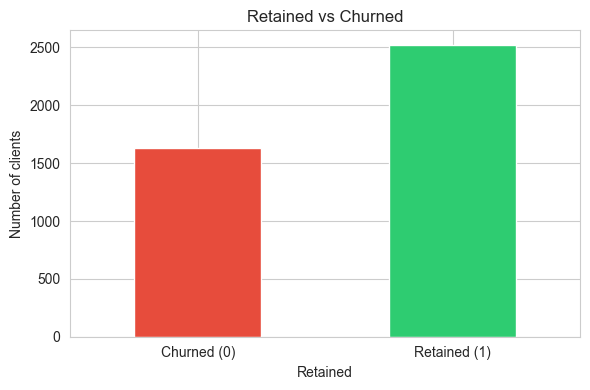

In [10]:
# count Retained target by index (first 0, then 1)
balance     = df_train['Retained'].value_counts().sort_index()
balance_pct = df_train['Retained'].value_counts(normalize=True).sort_index().round(3)

print("Counts:\n", balance, sep='')
print("\nProportions:\n", balance_pct, sep='')

# plot
fig, ax = plt.subplots(figsize=(6, 4))
balance.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Retained vs Churned')
ax.set_xticklabels(['Churned (0)', 'Retained (1)'], rotation=0)
ax.set_ylabel('Number of clients')
plt.tight_layout()
plt.show()

**Takeaway**: the target variable is moderately imbalanced, with 60.7% retained and 39.3% churned clients. This level of imbalance does not require resampling techniques but does rule out accuracy as a primary evaluation metric; we will use ROC-AUC and F1 as main metrics, with the majority-class baseline (60.7%) as our minimum bar for any model.

### 5.2 Missing values

Different columns have very different rates of missingness. A few patterns to notice:

- **`Early_RPL`** has many nulls — it's the first communication invitation date, likely
  only recorded when the school reached a certain funnel stage.
- **CRM meeting dates** (`FirstMeeting`, `LastMeeting`) are missing for schools that
  held no meetings.
- **`Special_Pay`** is missing for most rows — we'll let imputation handle it but a
  high missingness rate is itself a signal.


                                Count  Percent
Special_Pay                      3329     80.2
Early_RPL                        1168     28.1
rpl_window_days                  1168     28.1
DifferenceTraveltoFirstMeeting    661     15.9
LastMeeting                       661     15.9
FirstMeeting                      661     15.9
DifferenceTraveltoLastMeeting     661     15.9
To_Grade                          269      6.5
From_Grade                        226      5.4
SchoolSizeIndicator               169      4.1
FPP_to_School_enrollment          159      3.8
MDR_High_Grade                    126      3.0
SchoolGradeTypeLow                112      2.7
SchoolGradeType                   112      2.7
Total_School_Enrollment           112      2.7
Income_Level                      112      2.7
CRM_Segment                       112      2.7
SPR_New_Existing                  112      2.7
MDR_Low_Grade                     112      2.7
School_Type                       112      2.7


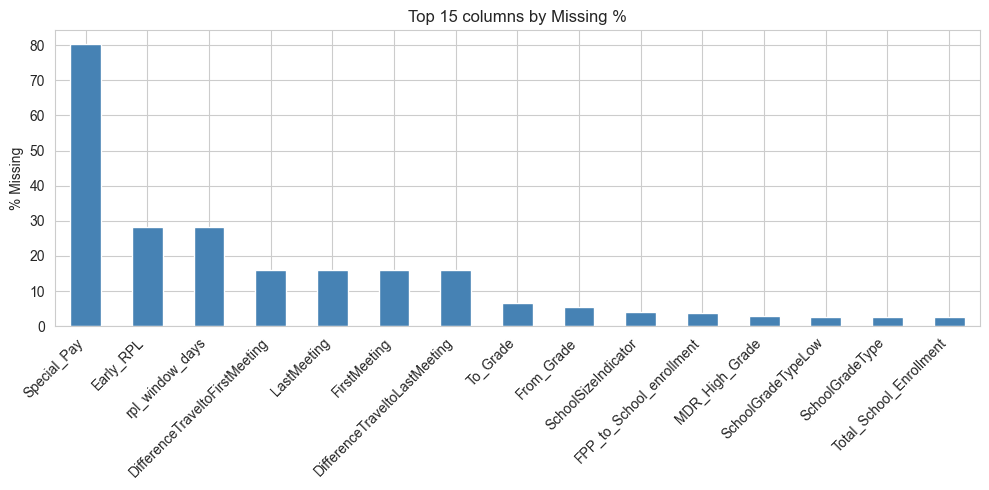

In [11]:
# count missing values per column (keep only missing > 0)
missing     = df_train.isnull().sum()
missing     = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_train) * 100).round(1)
print(pd.DataFrame({'Count': missing, 'Percent': missing_pct}).head(20))

# plot 
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 columns by Missing %')
ax.set_ylabel('% Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway**: 
- The `Special_Pay` column has about 80% missing values: only four rows have the value '0', and additionally 3,329 out of 4,153 training   rows have no value at all. 
- The four meeting-related columns (`DifferenceTraveltoFirstMeeting`, `LastMeeting`, `FirstMeeting`, `DifferenceTraveltoLastMeeting`) all have identical missingness (661). This implies that these fields are populated and/or missing as a group, probably because they come from the same system event or data source. If a booking doesn't have a FirstMeeting recorded, it won't have any of the meeting-related fields.
- Eight columns have 112 missing (2.7%): `SchoolGradeTypeLow`, `SchoolGradeType`, `Total_School_Enrollment`, `Income_Level`, `CRM_Segment`, `SPR_New_Existing`, `MDR_Low_Grade`, `School_Type`. This is in line with the previous coverage report: CRM coverage was 97.3%, meaning 2.7% of bookings have no CRM record --> that's exactly 112 rows (2.7% × 4,153 ≈ 112). All eight of these columns come from the CRM table, so they're missing as a block whenever the CRM join fails.

One thing to consider is the `Special_Pay` missingness: it might be important to test whether keeping the missing values, or dropping them, significantly changes the baseline model. 

To further confirm our analysis, we can quickly run the same missingness test on the test datasets:

In [12]:
missing_test = df_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
missing_test_pct = (missing_test / len(df_test) * 100).round(1)
print(pd.DataFrame({'Count': missing_test, 'Percent': missing_test_pct}).head(20))

                                Count  Percent
Special_Pay                       514     81.6
rpl_window_days                   179     28.4
Early_RPL                         179     28.4
DifferenceTraveltoFirstMeeting     94     14.9
FirstMeeting                       94     14.9
DifferenceTraveltoLastMeeting      94     14.9
LastMeeting                        94     14.9
To_Grade                           31      4.9
From_Grade                         28      4.4
SchoolSizeIndicator                24      3.8
FPP_to_School_enrollment           23      3.7
SchoolGradeTypeHigh                21      3.3
NumberOfMeetingswithParents        21      3.3
Total_School_Enrollment            21      3.3
CRM_Segment                        21      3.3
MDR_High_Grade                     21      3.3
MDR_Low_Grade                      21      3.3
Parent_Meeting_Flag                21      3.3
School_Type                        21      3.3
Region                             21      3.3


### 5.3 Target rate analysis by categorical variables

This analysis focuses on analyzing the target variable (**`Retained`**) to assess the predictive power of other categorical variables. We are basically computing churn/retain rate for each categorical feature.

**Note**: we initially considered the `Departure_Month` column, which only took on values "January" and "December", but after a quick check with the initial dataset we understood the presence of a **discrepancy** between the `Departure_Day` column and the actual `Departure_Month`, as presented here:


In [15]:
# Compare the two columns directly
pd.crosstab(df_train['DepartureMonth'], df_train['departure_month_num'])

# And check against actual departure dates
print(df_train[['DepartureMonth', 'departure_month_num', 'Departure_Date']].head(20))

# Also check if DepartureMonth might match another date column's month
print("DepartureMonth vs Initial_System_Date month:")
print(pd.crosstab(
    df_train['DepartureMonth'], 
    df_train['Initial_System_Date'].dt.month
))

   DepartureMonth  departure_month_num Departure_Date
0         January                    4     2019-04-07
1         January                    4     2019-04-30
2         January                    3     2019-03-17
3         January                    5     2019-05-08
4         January                    3     2019-03-17
5         January                    6     2019-06-23
6         January                    3     2019-03-07
7         January                    3     2019-03-09
8         January                    5     2019-05-03
9         January                    4     2019-04-29
10        January                    3     2019-03-30
11        January                    3     2019-03-16
12        January                    3     2019-03-09
13        January                    6     2019-06-16
14        January                    4     2019-04-29
15        January                    5     2019-05-17
16        January                    4     2019-04-27
17        January           

This highlights that the `Departure_Month` column does not accurately reflect the date information, which is instead correctly presented in `Departure_Date`. Indeed, `DepartureMonth` is documented as 'month of departure' but contains only 'January' (4,137) and 'December' (16), with actual `Departure_Date` values spanning March–June. Interpreted as a program cycle label; seasonal information extracted from `Departure_Date` directly via `departure_month_num`.

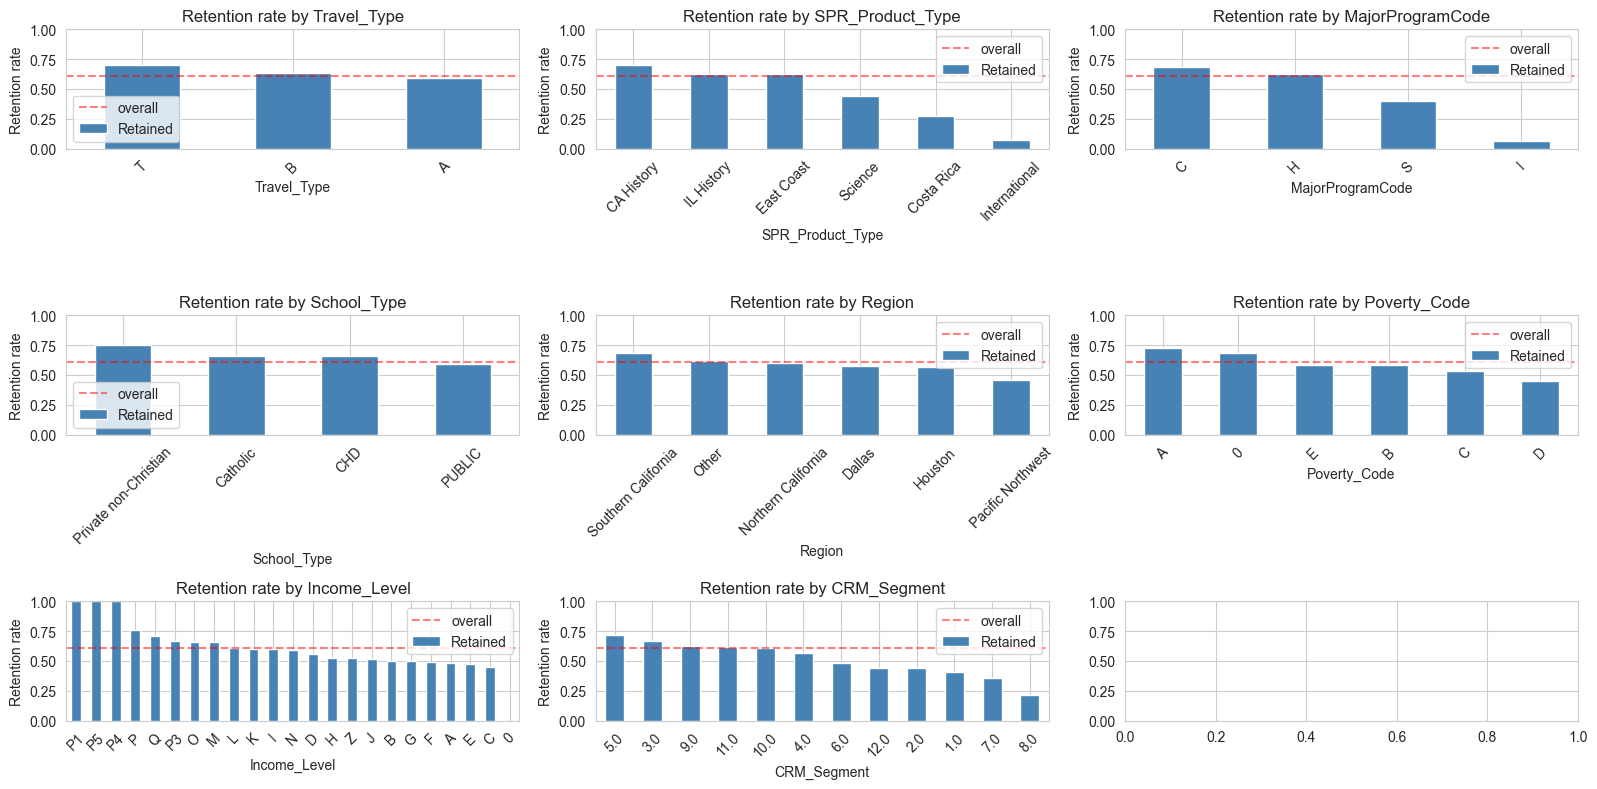

In [16]:
cat_features_to_check = ['Travel_Type', 'SPR_Product_Type', 'MajorProgramCode',
                         'School_Type', 'Region', 'Poverty_Code', 'Income_Level', 'CRM_Segment']


# only include categories that actually appear in the data
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cat_features_to_check):
    # split according to categorical column's value 
    # compute the average of the Retained target for each "bucket"
    rates = df_train.groupby(col, observed=True)['Retained'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Retention rate by {col}')
    ax.set_ylabel('Retention rate')
    ax.set_ylim(0, 1)
    # horizontal red line at overall Retention, 60.7% 
    # --> categories with bars above it retain better than average, categories below it retain worse. 
    ax.axhline(df_train['Retained'].mean(), color='red', ls='--', alpha=0.5, label='overall')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

If all bars for a categorical feature are roughly at the red line, the feature has no little to no predictive power (that is, retention is the same regardless of category); if the bars range from about 0.3 to 0.85, then the feature is highly predictive. It is also important to check the category sizes, because if a category only has a handful of rows then the target Retention could not be accurate. 

**Note**: we hand-picked the categorical variables to assess based primarily on readability. Indeed, the majority of chosen dimensions present 2 to 5 features, while for instance `Income_Level` has several features that make the graph not optimal for the purpose of our analysis. 

**Takeaway**: 


### 5.4 Numeric features vs target

For a few key numeric variables we look at their distribution split by target. Different
distributions between classes suggest the feature carries signal.


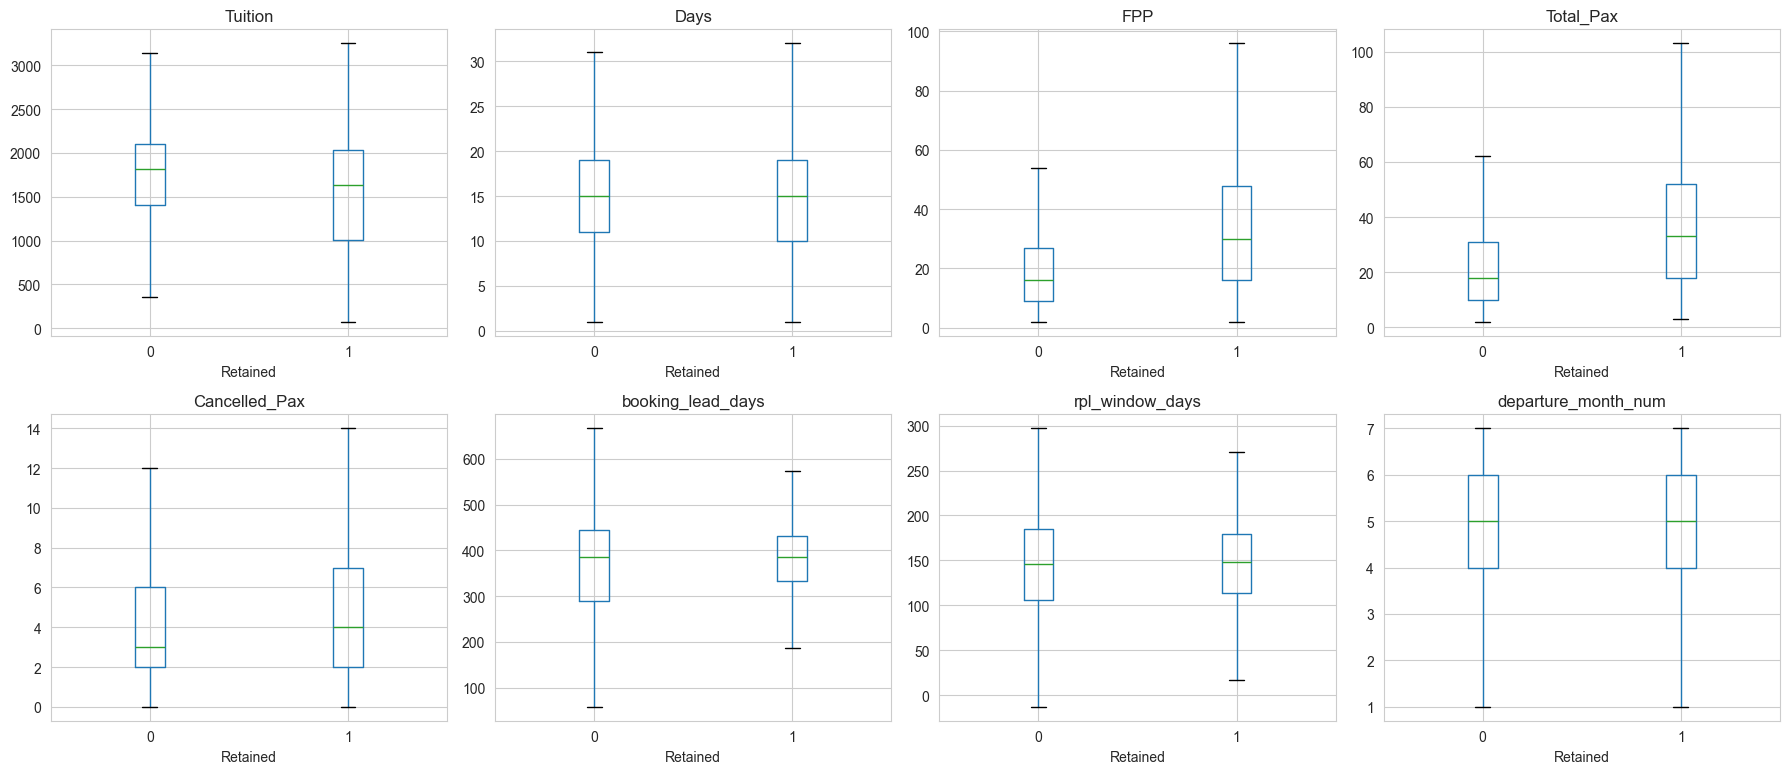

In [18]:
num_to_check = ['Tuition', 'Days', 'FPP', 'Total_Pax', 'Cancelled_Pax',
                'booking_lead_days', 'rpl_window_days', 'departure_month_num']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_to_check):
    df_train.boxplot(column=col, by='Retained', ax=ax, showfliers = False)
    ax.set_title(col)
    ax.set_xlabel('Retained')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 6. Final feature selection

Most of the work is already done by `preprocess()`. What remains is deciding which
columns to actually feed the model. We drop four types of columns:

- **Pure identifiers** (`ID_SALES`, `ID_FINANCE`, `ID_CRM`) — not predictive.
- **Raw dates** — already summarised by our engineered time-deltas. Keeping them would
  leak future information.
- **Redundant combos** — `GroupGradeType` is literally `Low + High`, so we drop the
  `Low`/`High` pair and keep the combo (or vice-versa).
- **Near-empty columns** already handled upstream.

We keep `ID_SALES` from the test set separately so we can attach it back to the
predictions at submission time.


In [ ]:
def select_features(df):
    """Drop columns that shouldn't be fed to the model."""
    df = df.copy()

    drop_cols = [
        # Identifiers
        'ID_SALES', 'ID_FINANCE', 'ID_CRM',
        # Raw dates (summarised by engineered deltas)
        'Departure_Date', 'Return_Date',
        'Early_RPL', 'Latest_RPL',
        'Initial_System_Date', 'Deposit_Date',
        'FirstMeeting', 'LastMeeting',
        # Redundant combos — keep the combined version, drop the parts
        'GroupGradeTypeLow', 'GroupGradeTypeHigh',
        'SchoolGradeTypeLow', 'SchoolGradeTypeHigh',
    ]
    return df.drop(columns=[c for c in drop_cols if c in df.columns])


# Keep test IDs before dropping them — we'll need them for the submission file
test_ids = df_test['ID_SALES'].copy()

# Split target from features
y_train = df_train['Retained']
X_train = select_features(df_train.drop(columns='Retained'))
X_test  = select_features(df_test)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
X_train.head(3)

## 7. Preprocessing pipeline

We now build the `ColumnTransformer` that sklearn will apply inside each CV fold.
This is what guarantees **no data leakage**: imputation medians, scaler means, and
one-hot categories are all learned on training folds only.

- **Numeric columns** (includes `Int8`, `float`, plain `int`): median imputation
  (robust to outliers) + standard scaling (needed for Logistic Regression; harmless
  for trees).
- **Categorical columns** (`object` and `category` dtypes): most-frequent imputation
  + one-hot encoding with `handle_unknown='ignore'` so unseen categories at prediction
  time don't crash the pipeline.

⚠️ **Important:** we use `select_dtypes(include='number')` and
`include=['object', 'category']` because our preprocessing produces `Int8` nullable
integers and `category` dtype. A naive `include=['int64', 'float64']` would silently
drop many features!


In [ ]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns ({len(num_cols)}):")
print("  " + ", ".join(num_cols))
print(f"\nCategorical columns ({len(cat_cols)}):")
print("  " + ", ".join(cat_cols))

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
])

## 8. Model comparison via cross-validation

We compare three progressively more complex models:

1. **Logistic Regression** — simple linear baseline. If a complex model can't beat this,
   the task is essentially linear and we should keep things simple.
2. **Random Forest** — non-linear, captures interactions, robust to outliers.
3. **Gradient Boosting** — usually the strongest classical tabular model.

Evaluation uses **5-fold stratified cross-validation** (stratified preserves class
balance across folds) and two metrics:

- **ROC-AUC** — captures ranking quality, threshold-independent.
- **F1** — balances precision and recall for the positive class.


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['roc_auc', 'f1'],
        return_train_score=False,
        n_jobs=-1,
    )
    results[name] = {
        'ROC-AUC':     scores['test_roc_auc'].mean(),
        'ROC-AUC std': scores['test_roc_auc'].std(),
        'F1':          scores['test_f1'].mean(),
        'F1 std':      scores['test_f1'].std(),
    }

results_df = pd.DataFrame(results).T.round(4)
print(results_df)

best_name = results_df['ROC-AUC'].idxmax()
print(f"\nBest model by ROC-AUC: {best_name}")

## 9. Final model — fit on all training data

Now that we've picked the winner, we refit it on the **full training set** (no hold-out
anymore — we want every labelled row before predicting on test).

We also extract **feature importances** from the tree-based model. This is what the
business team actually cares about: it tells us *why* churning customers churn.


In [ ]:
best_pipe = Pipeline([('prep', preprocessor), ('clf', models[best_name])])
best_pipe.fit(X_train, y_train)

# Extract post-one-hot feature names so importances are labelled correctly
if hasattr(models[best_name], 'feature_importances_'):
    ohe_cats = (
        best_pipe.named_steps['prep']
                 .named_transformers_['cat']
                 .named_steps['encoder']
                 .get_feature_names_out(cat_cols).tolist()
    )
    feature_names = num_cols + ohe_cats

    importances = pd.Series(
        best_pipe.named_steps['clf'].feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    print("Top 15 features:")
    print(importances.head(15).round(4))

    fig, ax = plt.subplots(figsize=(9, 6))
    importances.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 15 feature importances — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 10. Generating predictions for the test set

Final step: apply the trained pipeline to the test set and save predictions in the
format required by the assignment (`ID_SALES, Retained`).


In [ ]:
test_preds = best_pipe.predict(X_test)

submission = pd.DataFrame({
    'ID_SALES': test_ids,
    'Retained': test_preds,
})

submission.to_csv('predictions.csv', index=False)

print(f"Saved {len(submission)} predictions to predictions.csv")
print("\nPrediction distribution:")
print(submission['Retained'].value_counts())
print("\nFirst 10 predictions:")
print(submission.head(10))

## 11. Business takeaways

This section drives the presentation's narrative. Based on the feature importances, we
can profile churn risk and suggest concrete retention levers:

- **Time-related features** (`booking_lead_days`, `rpl_window_days`, `deposit_lead_days`)
  suggest that **how early and for how long a client engages** with the agency matters.
  Agents could actively nurture clients with short RPL windows — they're at higher risk.
- **Finance features** (`FRP_Take_up_percent_`, `EZ_Pay_Take_Up_Rate`, `Tuition`)
  reflect the client's financial commitment. Low take-up on insurance or direct debit
  may indicate weaker attachment to the service.
- **CRM engagement** (`NumberOfMeetingswithParents`, `Parent_Meeting_Flag`,
  `has_crm_data`) suggests **human contact matters**. Schools with more parent meetings
  are more likely to return.
- **Operational features** (`cancellation_rate`, `Days`) capture the trip experience —
  high cancellation rates or outlier durations may correlate with churn.

### Recommended actions for Yeti Travel

1. **Early-warning dashboard** — flag accounts whose predicted churn probability exceeds
   a threshold and route them to a dedicated retention agent.
2. **Parent meetings as a retention lever** — proactively promote meetings for schools
   with zero recorded meetings.
3. **Engagement-depth policy** — encourage early booking and full-duration RPL campaigns
   through time-limited incentives.
4. **Customer satisfaction tracking** — as Angela originally hinted, the biggest blind
   spot is the lack of direct satisfaction data. A simple post-trip survey would add
   powerful signal to future iterations of the model.
